# 06 · Residual 1-D CNN — PyTorch

The baselines in notebook 05 fed a shallow model 194 numbers. This one drops the
engineered descriptors entirely and hands the network the **raw 187-sample
waveform**, because that is where the EDA located the signal: no scalar descriptor
correlates with the label above r = 0.27, while the class median morphologies are
visibly different.

The architecture is the residual CNN of Kachuee, Fazeli & Sarrafzadeh
([arXiv:1805.00794](https://arxiv.org/abs/1805.00794)): one convolution, five
residual blocks, two fully-connected layers — about 54k parameters.

```bash
python scripts/train_cnn.py --source mitbih                              # weighted loss
python scripts/train_cnn.py --source mitbih --no-class-weights --tag unweighted
```

> **Fitting happens in the scripts, not in the notebooks.** Every model here was
> produced by a command shown at the top of its section; the notebook reloads the
> saved model and re-runs inference live, so the tables and figures below come
> from the fitted estimator rather than from a cached CSV that could drift from
> it. That keeps notebook execution fast and the artefacts in `reports/`
> guaranteed consistent with what the repository ships.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

try:
    import ecg
except ModuleNotFoundError:
    sys.path.insert(0, str(Path.cwd().parent / "src"))
    import ecg

print("ecg", ecg.__version__)

ecg 0.1.0


In [2]:
import json

import numpy as np
import pandas as pd
import torch

from ecg import eda, metrics, viz
from ecg.config import load_config
from ecg.models import ResidualCNN, describe
from ecg.session import get_spark, stop_spark
from ecg.torch_data import class_weights, describe_arrays, load_arrays, make_loaders
from ecg.training import evaluate_model, load_checkpoint, predict

pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 30)
torch.set_num_threads(2)

cfg = load_config()
viz.apply_style()

SOURCE = "mitbih"
LABELS = eda.ordered_labels(SOURCE)

spark = get_spark(cfg)
spark.sparkContext.setLogLevel("ERROR")
arrays = load_arrays(spark, cfg, source=SOURCE)
stop_spark(spark)

describe_arrays(arrays, LABELS)

,split,n_beats,samples,N,S,V,F,Q
0,train,74418,187,61600,1889,4919,544,5466
1,val,13136,187,10871,334,869,97,965
2,test,21892,187,18118,556,1448,162,1608


## 1 · The architecture

Five pooling stages take a 187-sample beat down to 2 positions × 32 channels. The
skip connections are what let five blocks train without the gradient vanishing on
a signal this short.

In [3]:
model = ResidualCNN(n_classes=len(LABELS))
describe(model)

{'architecture': 'ResidualCNN',
 'n_classes': 5,
 'input_length': 187,
 'flat_dim': 64,
 'parameters': 53957,
 'trainable_parameters': 53957}

In [4]:
# Trace the tensor through the network with forward hooks.
shapes = []
handles = [model.stem.register_forward_hook(
    lambda m, i, o: shapes.append({"stage": "stem convolution", "shape": tuple(o.shape[1:])}))]
for index, block in enumerate(model.blocks, start=1):
    handles.append(block.register_forward_hook(
        lambda m, i, o, n=index: shapes.append(
            {"stage": f"residual block {n}", "shape": tuple(o.shape[1:])})))
handles.append(model.head.register_forward_hook(
    lambda m, i, o: shapes.append({"stage": "classifier head", "shape": tuple(o.shape[1:])})))

with torch.no_grad():
    model(torch.zeros(1, 1, 187))
for handle in handles:
    handle.remove()

pd.DataFrame([{"stage": "input", "shape": (1, 187)}] + shapes)

,stage,shape
0,input,"(1, 187)"
1,stem convolution,"(32, 187)"
2,residual block 1,"(32, 92)"
3,residual block 2,"(32, 44)"
4,residual block 3,"(32, 20)"
5,residual block 4,"(32, 8)"
6,residual block 5,"(32, 2)"
7,classifier head,"(5,)"


## 2 · Training protocol

Weighted cross-entropy with the same balanced weights the Spark models used, Adam,
`ReduceLROnPlateau`, and **early stopping on validation macro-F1** rather than on
loss.

In [5]:
loaders = make_loaders(arrays, batch_size=cfg.batch_size, seed=cfg.seed)
weights = class_weights(arrays["train"][1], len(LABELS))
pd.DataFrame({"class": LABELS,
              "train beats": np.bincount(arrays["train"][1]),
              "loss weight": [round(float(w), 3) for w in weights]})

,class,train beats,loss weight
0,N,61600,0.242
1,S,1889,7.879
2,V,4919,3.026
3,F,544,27.360
4,Q,5466,2.723


In [6]:
history = pd.read_csv(cfg.tables_dir / "mitbih_cnn_history.csv")
best_epoch = int(history.loc[history["val_macro_f1"].idxmax(), "epoch"])
print(f"{len(history)} epochs · best epoch {best_epoch} · "
      f"best val macro-F1 {history['val_macro_f1'].max():.4f} · "
      f"{history['seconds'].sum() / 60:.1f} min on 2 CPU cores")
history[["epoch", "train_loss", "val_loss", "val_macro_f1", "learning_rate"]].iloc[
    [0, 4, 9, 19, 29, 39, 49, best_epoch - 1, len(history) - 1]
].drop_duplicates()

60 epochs · best epoch 58 · best val macro-F1 0.9132 · 23.6 min on 2 CPU cores


,epoch,train_loss,val_loss,val_macro_f1,learning_rate
0,1,0.78241,0.47676,0.5710,0.001000
4,5,0.25784,0.26327,0.6412,0.001000
9,10,0.16859,0.23489,0.7800,0.001000
19,20,0.07111,0.28536,0.8591,0.000500
29,30,0.02683,0.41842,0.8872,0.000250
39,40,0.01091,0.57228,0.8993,0.000063
49,50,0.00864,0.68242,0.9086,0.000063
57,58,0.00546,0.81680,0.9132,0.000031
59,60,0.00520,0.75954,0.9115,0.000031


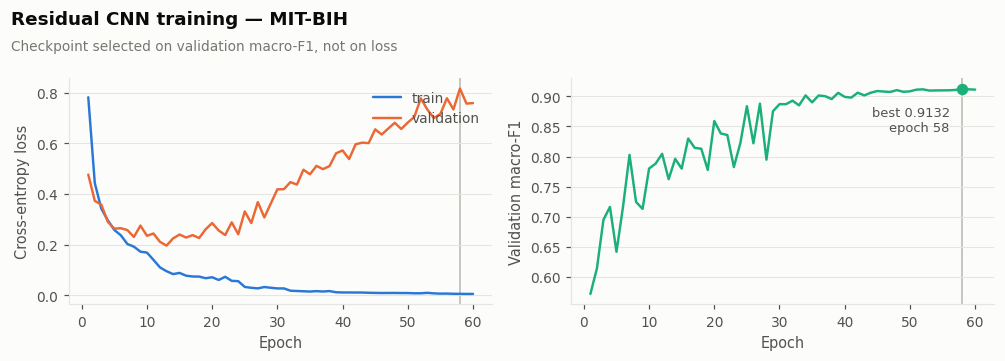

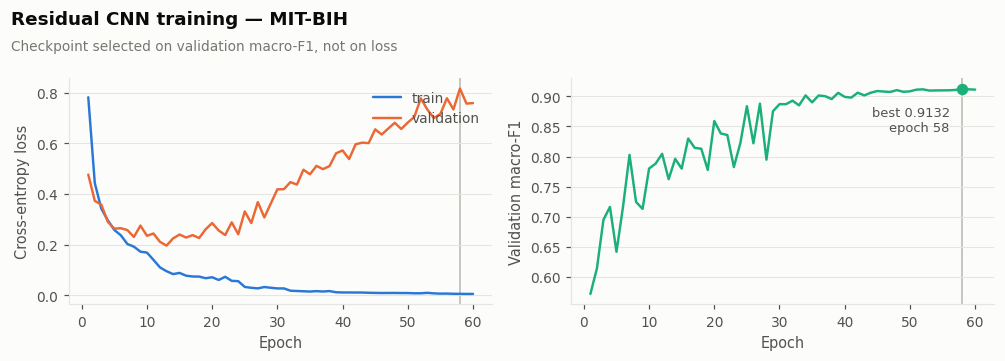

In [7]:
viz.plot_training_curves(
    history,
    title="Residual CNN training — MIT-BIH",
    subtitle="Checkpoint selected on validation macro-F1, not on loss",
    best_epoch=best_epoch,
)

In [8]:
# Two checkpoint-selection rules, side by side.
by_loss = history.loc[history["val_loss"].idxmin()]
by_f1 = history.loc[history["val_macro_f1"].idxmax()]

pd.DataFrame([
    {"selection rule": "lowest validation loss", "epoch": int(by_loss["epoch"]),
     "val_loss": by_loss["val_loss"], "val_macro_f1": by_loss["val_macro_f1"]},
    {"selection rule": "highest validation macro-F1", "epoch": int(by_f1["epoch"]),
     "val_loss": by_f1["val_loss"], "val_macro_f1": by_f1["val_macro_f1"]},
]).set_index("selection rule")

,epoch,val_loss,val_macro_f1
selection rule,,,
lowest validation loss,13,0.19604,0.7622
highest validation macro-F1,58,0.81680,0.9132


**Finding — early stopping on loss would have stopped far too early.** The
validation loss bottoms out at epoch 13 and then climbs steadily for the remaining
47 epochs, while validation macro-F1 keeps improving throughout. Both are true at
once: the network becomes *more confident and more wrong* on the 10,871 normal
validation beats — which is what the loss integrates over — while it keeps getting
*better at the 97 fusion beats*, which macro-F1 weights equally.

The cost is not marginal: the lowest-validation-loss checkpoint sits at epoch 13
with **macro-F1 0.762**, against **0.913** for the checkpoint this project actually
selects. Stopping on loss would have thrown away 15 points.

## 3 · Test performance

In [9]:
load_checkpoint(model, cfg.model_path("mitbih_cnn.pt"))
evaluation = evaluate_model(model, loaders["test"], LABELS, "residual-cnn", "test")
pd.Series(evaluation["summary"]).to_frame("residual CNN (test)")

,residual CNN (test)
model,residual-cnn
split,test
n,21892
macro_f1,0.9166
weighted_f1,0.984
balanced_accuracy,0.9258
accuracy,0.984
mcc,0.9475
cohen_kappa,0.9475
roc_auc_ovr_macro,0.9936


In [10]:
evaluation["per_class"]

,class,precision,recall,f1,support
0,N,0.9924,0.9913,0.9919,18118
1,S,0.8309,0.8309,0.8309,556
2,V,0.9539,0.9579,0.9559,1448
3,F,0.7722,0.8580,0.8129,162
4,Q,0.9925,0.9907,0.9916,1608
5,macro avg,0.9084,0.9258,0.9166,21892
6,weighted avg,0.9842,0.9840,0.9840,21892


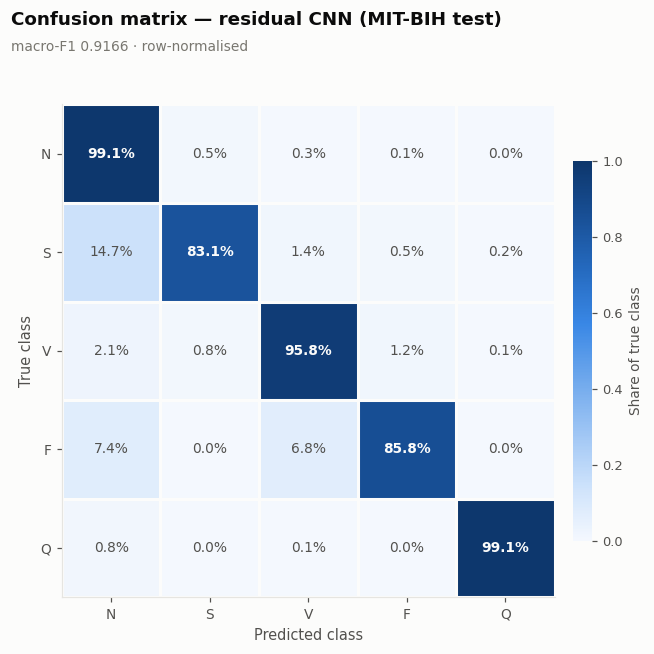

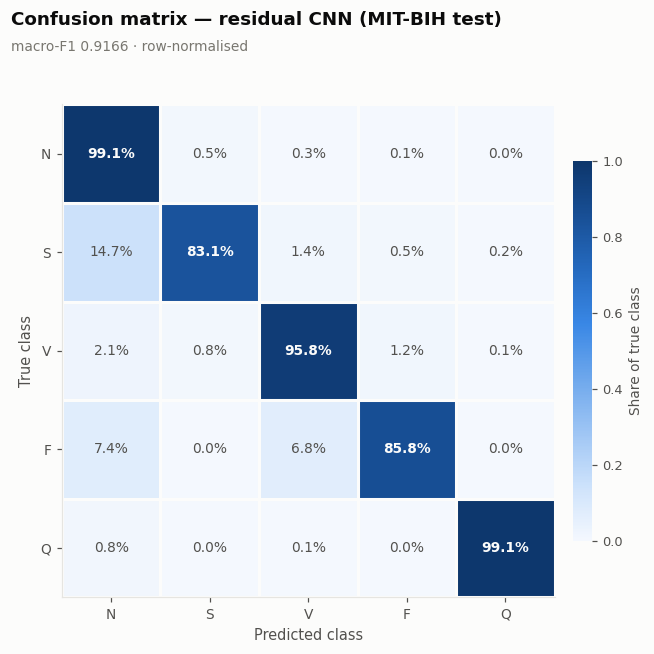

In [11]:
viz.plot_confusion_matrix(
    evaluation["confusion_normalised"],
    title="Confusion matrix — residual CNN (MIT-BIH test)",
    subtitle=f"macro-F1 {evaluation['summary']['macro_f1']:.4f} · row-normalised",
    normalised=True,
)

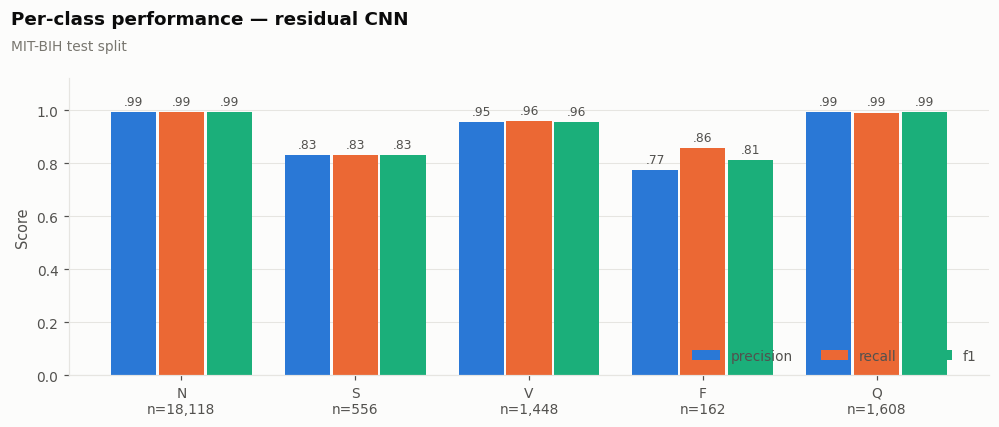

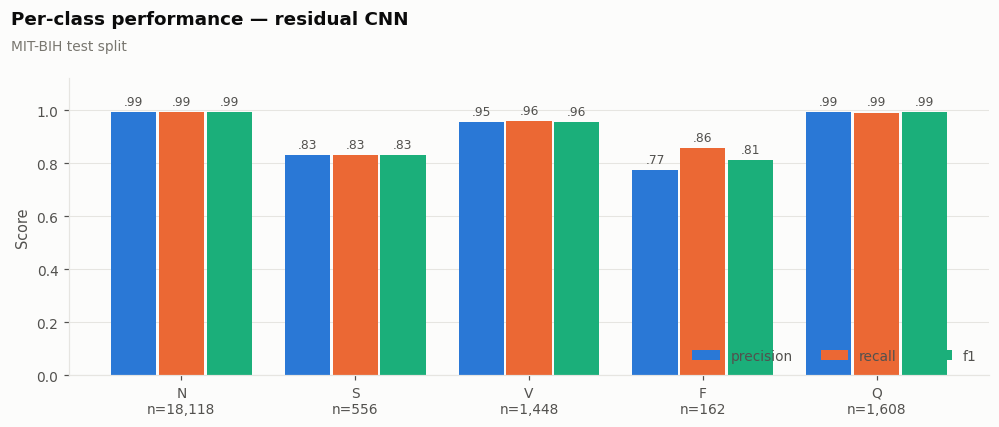

In [12]:
viz.plot_per_class_metrics(
    evaluation["per_class"], order=LABELS,
    title="Per-class performance — residual CNN",
    subtitle="MIT-BIH test split",
)

## 4 · Reading the errors

In [13]:
y_true, y_pred, y_score = predict(model, loaders["test"])
confusions = (
    pd.DataFrame({"true": y_true, "pred": y_pred})
    .query("true != pred")
    .value_counts()
    .head(6)
    .rename("n_beats")
    .reset_index()
)
confusions["true"] = confusions["true"].map(lambda i: LABELS[i])
confusions["pred"] = confusions["pred"].map(lambda i: LABELS[i])
confusions

,true,pred,n_beats
0,N,S,83
1,S,N,82
2,N,V,46
3,V,N,30
4,N,F,20
5,V,F,18


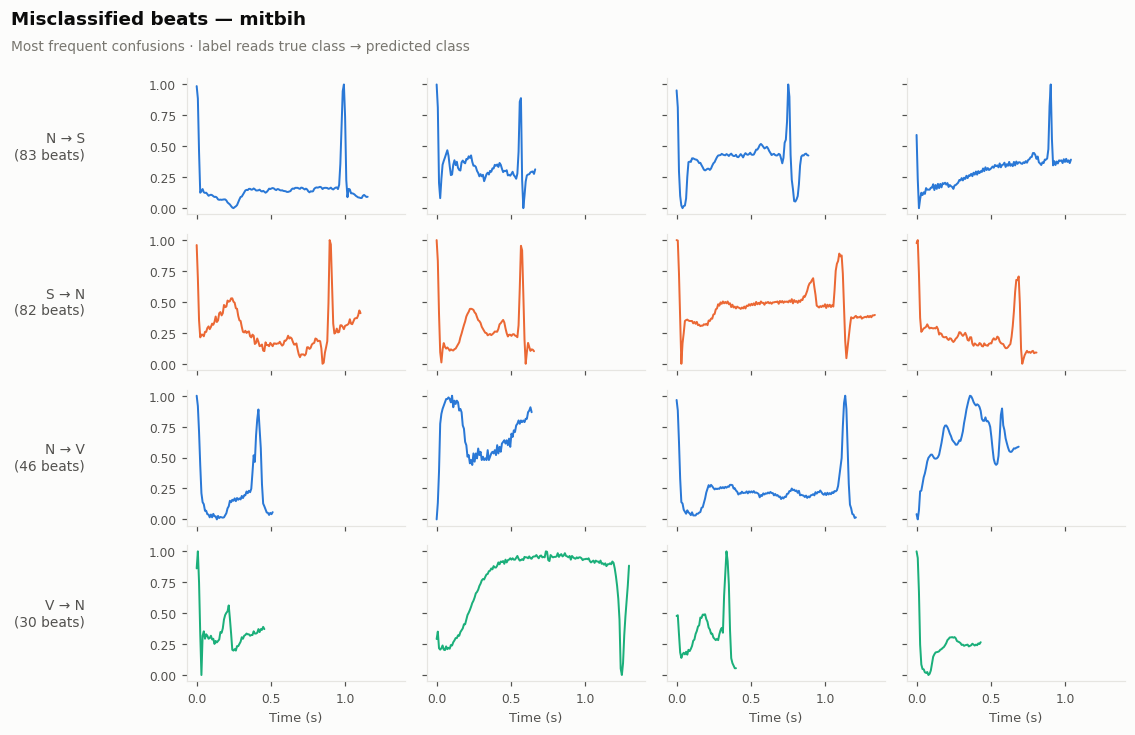

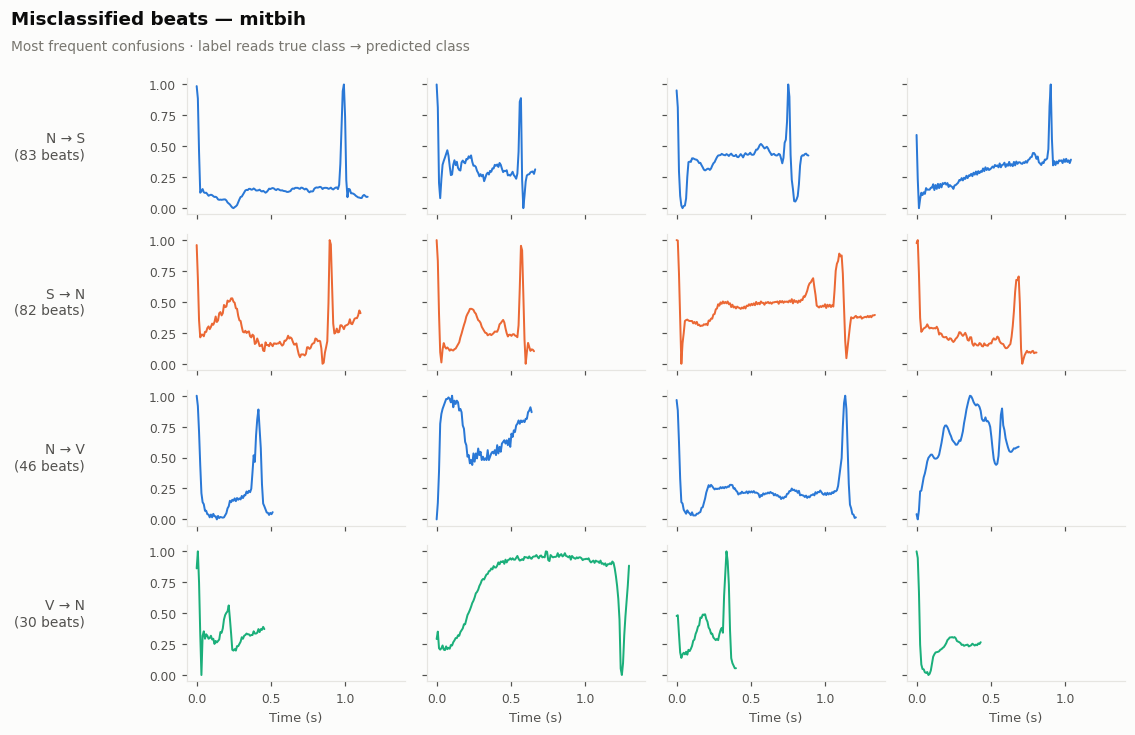

In [14]:
viz.plot_error_examples(
    arrays["test"][0], y_true, y_pred, LABELS, SOURCE, n_examples=4, seed=cfg.seed
)

## 5 · Ablation — what does the class weighting buy?

In [15]:
def load_summary(slug):
    return json.loads((cfg.tables_dir / f"{slug}_summary.json").read_text())

ablation = pd.DataFrame([
    {**load_summary("mitbih_cnn_test"), "loss": "weighted"},
    {**load_summary("mitbih_cnn_unweighted_test"), "loss": "unweighted"},
])
ablation[["loss", "macro_f1", "balanced_accuracy", "accuracy", "weighted_f1", "mcc"]]

,loss,macro_f1,balanced_accuracy,accuracy,weighted_f1,mcc
0,weighted,0.9166,0.9258,0.9840,0.9840,0.9475
1,unweighted,0.9147,0.8877,0.9836,0.9831,0.9454


In [16]:
recall = pd.concat([
    pd.read_csv(cfg.tables_dir / "mitbih_cnn_test_per_class.csv").assign(loss="weighted"),
    pd.read_csv(cfg.tables_dir / "mitbih_cnn_unweighted_test_per_class.csv").assign(loss="unweighted"),
])
recall = recall[recall["class"].isin(LABELS)]
comparison = recall.pivot(index="class", columns="loss", values="recall").reindex(LABELS)
comparison["delta"] = (comparison["weighted"] - comparison["unweighted"]).round(4)
comparison

loss,unweighted,weighted,delta
class,,,
N,0.9952,0.9913,-0.0039
S,0.7554,0.8309,0.0755
V,0.9496,0.9579,0.0083
F,0.7531,0.8580,0.1049
Q,0.9851,0.9907,0.0056


**Finding — the weighting moves the operating point, not the score.** Macro-F1 is
essentially unchanged (0.9166 weighted against 0.9147 unweighted), but these are
not the same model. Weighting buys **+7.6 points of recall on `S` and +10.5 on
`F`** and pays **−5.7 and −13.8 points of precision** on those same two classes.
Balanced accuracy, which averages recall alone, rises 3.8 points; per-class F1,
which charges for the false positives recall was bought with, barely moves.

This is worth stating precisely, because the easy claim — *weighting is what makes
the rare classes work* — is not what the data says. For the **linear** baselines in
notebook 05 weighting was decisive: without it they collapse toward the majority
class. For a network with enough capacity to separate the classes outright, it
selects an **operating point** instead.

Which point you want is a clinical question, not a modelling one. A screening tool
that must not miss a fusion beat wants the weighted model's recall and will accept
reviewing more false alarms for it; that is why weighting stays the default here.

## 6 · Against the classical baselines

In [17]:
baselines = pd.read_csv(cfg.tables_dir / "mitbih_baselines_test.csv")
trivial = json.loads((cfg.tables_dir / "mitbih_majority_baseline_summary.json").read_text())

overall = metrics.comparison_table(
    baselines.to_dict("records")
    + [{**evaluation["summary"], "model": "residual-cnn"}]
    + [trivial]
)
overall[["model", "macro_f1", "balanced_accuracy", "accuracy", "weighted_f1", "mcc"]]

,model,macro_f1,balanced_accuracy,accuracy,weighted_f1,mcc
0,residual-cnn,0.9166,0.9258,0.9840,0.9840,0.9475
1,random-forest,0.8323,0.8654,0.9668,0.9679,0.8903
2,gradient-boosted-trees,0.6724,0.8870,0.8775,0.8972,0.7045
3,logistic-regression,0.4971,0.7869,0.6834,0.7477,0.4631
4,linear-svc,0.4876,0.7908,0.6623,0.7315,0.4536
5,majority-class,0.1811,0.2000,0.8276,0.7495,0.0000


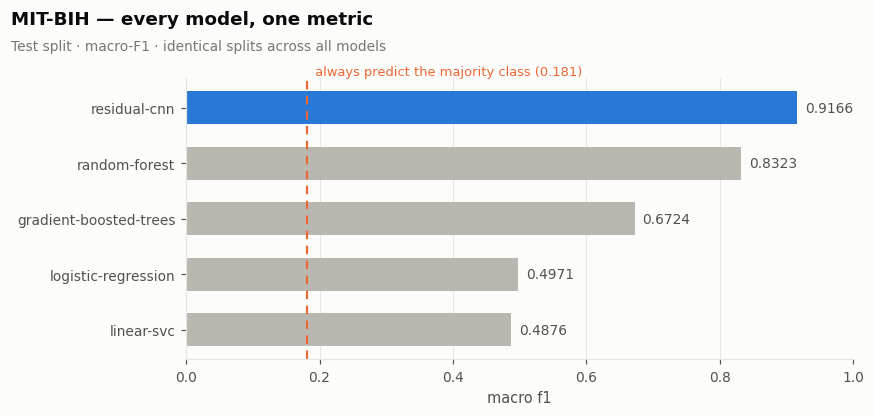

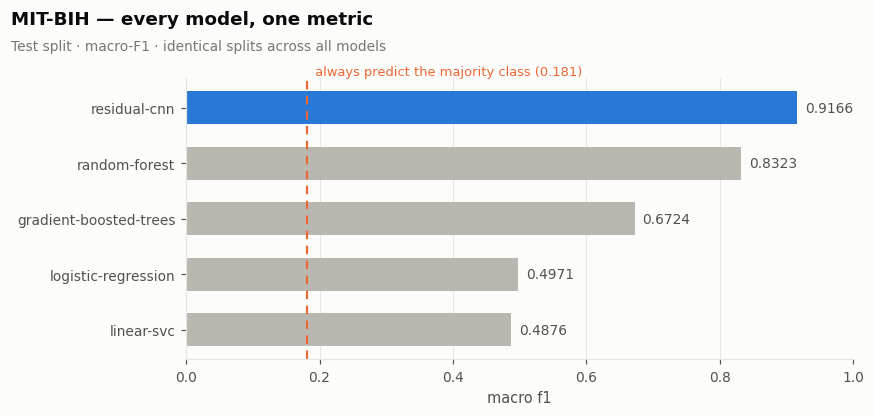

In [18]:
viz.plot_model_comparison(
    overall[overall["model"] != "majority-class"],
    metric="macro_f1",
    title="MIT-BIH — every model, one metric",
    subtitle="Test split · macro-F1 · identical splits across all models",
    reference=float(trivial["macro_f1"]),
    reference_label="always predict the majority class",
)

## Takeaways

| | |
|---|---|
| Residual CNN | **macro-F1 0.917**, balanced accuracy 0.926, accuracy 0.984 |
| Best classical model | random forest, macro-F1 0.832 |
| Where the gain is | `S` recall 0.83 and `F` recall 0.86 — the two classes the baselines could not read |
| Cost | 54k parameters, ~24 min on 2 CPU cores, no GPU |
| Metric choice | selecting on macro-F1 rather than loss is worth several points here |

The convolutions are reading morphology the 194-dimensional feature vector could
not express — which is exactly what the EDA predicted when no scalar descriptor
correlated with the label above r = 0.27.

Next: **07 · Transfer learning**, which takes this representation to PTB.